In [3]:
import os
import time
import tracemalloc
from namap_main import *
import pickle
import copy
import io
import cProfile
import pstats
import matplotlib.pyplot as plt
import sysconfig, site, os
from astropy.io import fits
from powspec import power_spectral_density
import astropy.units as u
import matplotlib.cm as cm
import pickle

def format_duration(hours):

    total_seconds = int(hours * 3600)
    h = total_seconds // 3600
    m = (total_seconds % 3600) // 60
    s = total_seconds % 60
    
    return f"{h}h{m}min{s}sec"

In [4]:
def my_p2(data_map, res, k_bins, unitpk=None, unitk=None, map2 = None, linearbinTrue_logbinFalse = False):

    ny,nx = data_map.shape
    npix = ny*nx
    norm =  ((res.to(u.rad))**2).to(u.sr) / npix

    k_map  =  give_map_spatial_freq(res, ny, nx) #rad-1
    
    if(map2 is not None):
        ft  = np.fft.fft2( data_map)
        ft1 = np.fft.fft2( map2)
        p2  = np.real(0.5*( (ft*np.conj(ft1)) + (np.conj(ft)*ft1) ))  * norm
    else: p2 = np.abs( (np.fft.fft2( data_map))**2) * norm
    
    histo, edegs = np.histogram(k_map, bins = k_bins)
    pk_1d, edges = np.histogram(k_map, bins = k_bins, weights = p2)
    pk_1d /= histo

    if linearbinTrue_logbinFalse: k = k_bins[:-1] + np.diff(k_bins)/2
    else: 
        k, edges = np.histogram(k_map, bins = k_bins, weights = k_map)
        k /= histo
    if(unitpk is None): return pk_1d, k
    else: return pk_1d.to(unitpk), k.to(unitk)

def give_map_spatial_freq(res, ny, nx):
    
    res = res.to(u.rad)
    Ys, Xs = np.unravel_index(np.arange(nx*ny),(ny,nx))
    N = np.zeros((ny, nx))
    M = np.zeros((ny, nx))
    for  xs, ys, in zip(Xs, Ys):
        N[ys,xs] = int(xs)
        M[ys,xs] = int(ys)
    w_sup = np.where(M>ny/2)
    M[w_sup] = ny - M[w_sup]
    w_sup = np.where(N>nx/2)
    N[w_sup] = nx - N[w_sup]
    Kx = N/nx/res
    Ky = M/ny/res
    k_map = (Kx**2 + Ky**2)**(1/2)
        
    return k_map

def make_bintab(k, delta_k_min, dkk = 0, delta_k_max=0, ):
    kmax      = k[1].value
    kmin      = k[0].value
    if(dkk == 0): 
        delta_k_min *= 4
        bintab = np.arange(kmin, kmax, delta_k_min.value )
        bin_width = np.ones(len(bintab)-1) * delta_k_min.value
    else:
        k1 = kmin
        delta_k = 0 
        bintab = []
        bintab.append(kmin)
        bin_width = []
        while(k1 + delta_k <= kmax):
            delta_k = np.minimum( np.maximum(k1*dkk, delta_k_min.value) , (kmax - k1) )
            if(delta_k_max != 0): 
                delta_k = np.minimum(delta_k, delta_k_max.value)
            k1 = k1 +  delta_k
            bintab.append(k1)
            bin_width.append(delta_k)
        bintab = np.asarray(bintab) 
    if( bintab.max() <= kmax):
        bintab[-1]    = kmax
        bin_width[-1] = bintab[-1]-bintab[-2]
    #bintab = np.insert(bintab,0,0)
    return bintab * k[0].unit , bin_width * k[0].unit
    
def set_k_infos(ny, nx, res, delta_k_over_k = 0):

    #compute the maximum value of l
    k_nyquist = 2 / res.to(u.rad)  #rad**-1
    #compute the map of the radial l multipols
    k_map  =  give_map_spatial_freq(res, ny, nx) #rad-1
    #Measuring from the map of l the miminum value of l
    k_min = np.min(k_map[np.nonzero(k_map)]) #rad-1
    #Computing the minimum size of a l bin
    dk_min = 2 / ( np.minimum(ny,nx) * res.to(u.rad)) #rad-1

    k_range = [k_min, k_nyquist] #rad**-1
    #Setting the binning of the l map
    k_bin_tab, k_bin_width = make_bintab(k_range, dk_min, delta_k_over_k) #rad-1 
    #Compute bin addresses
    k_out, edges = np.histogram(k_map, bins = k_bin_tab, weights = k_map)
    histo, edegs = np.histogram(k_map, bins = k_bin_tab)
    k_out = k_out / histo
    if(delta_k_over_k == 0): k_out = k_bin_tab[:-1] + np.diff(k_bin_tab)/2
    return k_nyquist, k_min, k_bin_width, k_bin_tab, k_out, k_map

Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


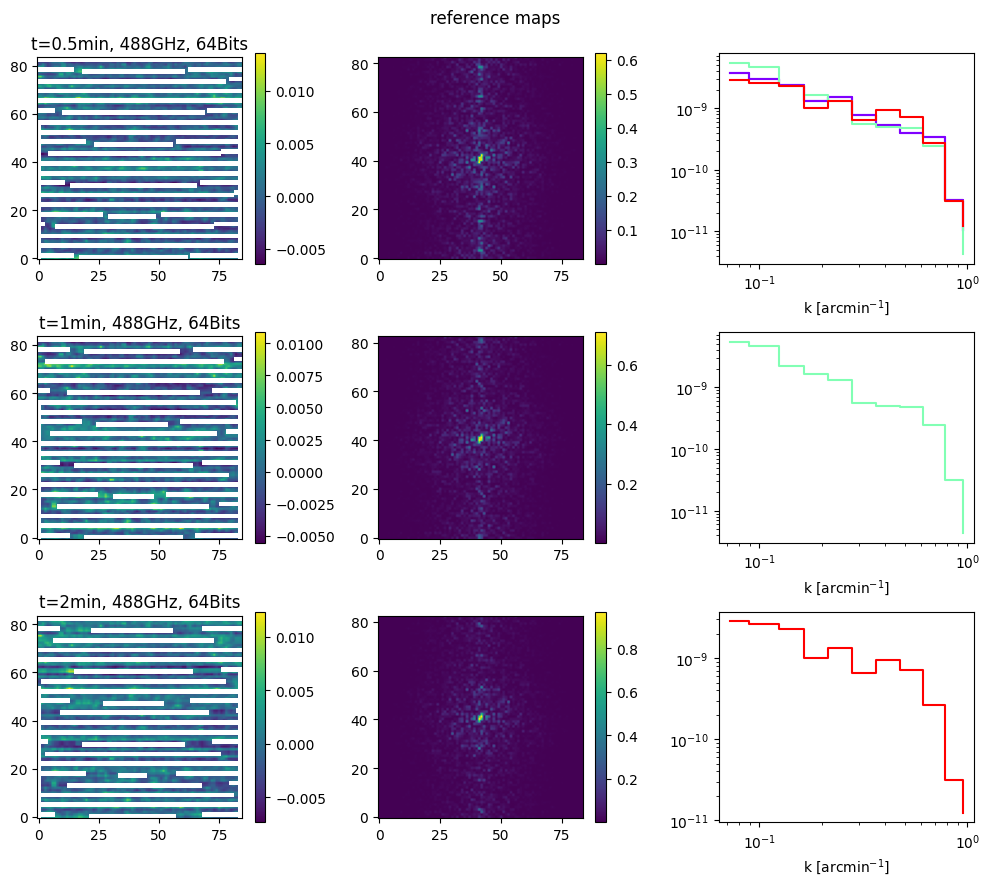

In [5]:
#Reference coadded map
dictname = 'fits_and_hdf5/reference_coadded_maps.p'

res = 40
times = (0.5,1,2)
colors = cm.rainbow(np.linspace(0,1,len(times)))


if(not os.path.isfile(dictname) or True ): 
    dict = {}

    fig, axs = plt.subplots(len(times),3,figsize=(10,len(times)*3))
    fig.suptitle('reference maps')
    for t, (time, c) in enumerate(zip(times,colors)):
        dict[f't={format_duration(time/60)}'] = {}
        #---
        
        par = load_par_file(f'params_ref_namap.par')
        file = f'TOD_{format_duration(time/60)}_64bits_data488.0Hz_coords488.0Hz.hdf5'
        par['hdf5_file'] = f'/home/mvancuyck/Desktop/TODs_profiling/{file}' 
        par['cdelt'] = res/3600, res/3600
        par['output_map'] = f"coadded_map_{len(par['frequencies'])}bands_{file[-5]}.fits"
        par['bypass_synch'] = True
        main(par)
        #---

        Map = fits.getdata(f"fits_and_hdf5/{par['output_map']}")
        dict[f't={format_duration(time/60)}']['map'] = Map
        dict[f't={format_duration(time/60)}']['res ["]'] = res
        im = axs[t,0].imshow(Map, origin='lower'); 
        axs[t,0].set_title(f't={time}min, 488GHz, 64Bits')
        fig.colorbar(im, ax=axs[t,0], orientation='vertical')
        Map = np.nan_to_num(Map, nan=0.0, posinf=0.0, neginf=0.0)
        fft2 = np.fft.fft2(Map)
        fft2_shifted = np.fft.fftshift(fft2[1:,1:])  # center zero frequency
        power = np.abs(fft2_shifted)**2
        im2 = axs[t,1].imshow(power, origin='lower')
        dict[f't={format_duration(time/60)}']['power'] = power
        fig.colorbar(im2, ax=axs[t,1], orientation='vertical')
        k_nyquist, k_min, k_bin_width, k_bin_tab, k_out, k_map = set_k_infos(Map.shape[0], Map.shape[1], res/3600*u.deg, delta_k_over_k = 0.3)
        pk,k = power_spectral_density(Map, res=res/3600*u.deg, bins=k_bin_tab)
        axs[t,2].step(k_out[1:].to(1/u.arcmin),pk[1:], where='mid',color=c)
        axs[0,2].step(k_out[1:].to(1/u.arcmin),pk[1:], where='mid',color=c)
        axs[t,2].set_xscale('log'); axs[t,2].set_yscale('log')
        axs[t,2].set_xlabel('k [$\\rm arcmin^{-1}$]')
        dict[f't={format_duration(time/60)}']['pk'] = pk[1:]
        dict[f't={format_duration(time/60)}']['k [arcmin-1]'] = k_out[1:].to(1/u.arcmin)
        fig.tight_layout()

    pickle.dump(dict, open(dictname, 'wb'))
else: dict =  pickle.load( open(dictname, 'rb'))

dict_ref = dict


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


...

/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


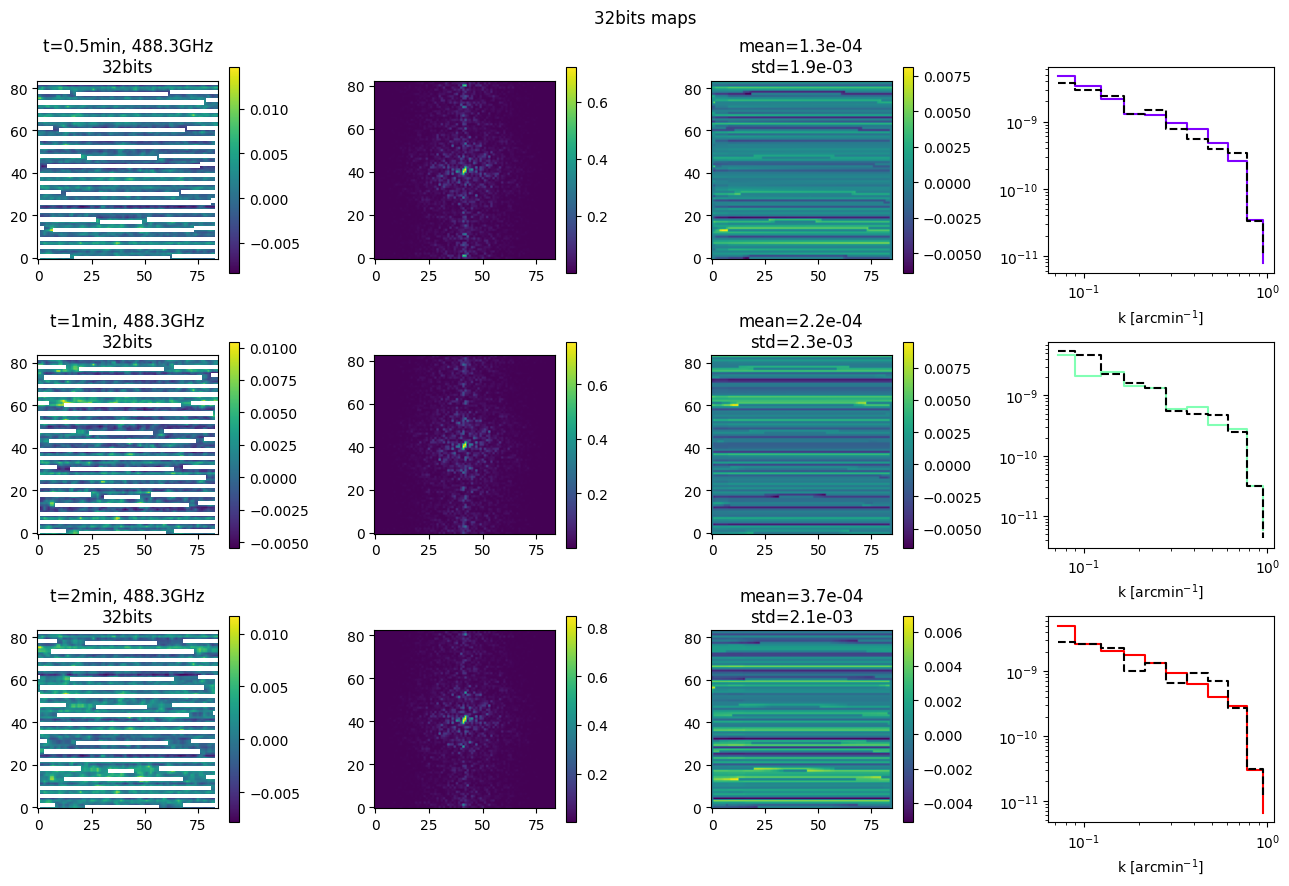

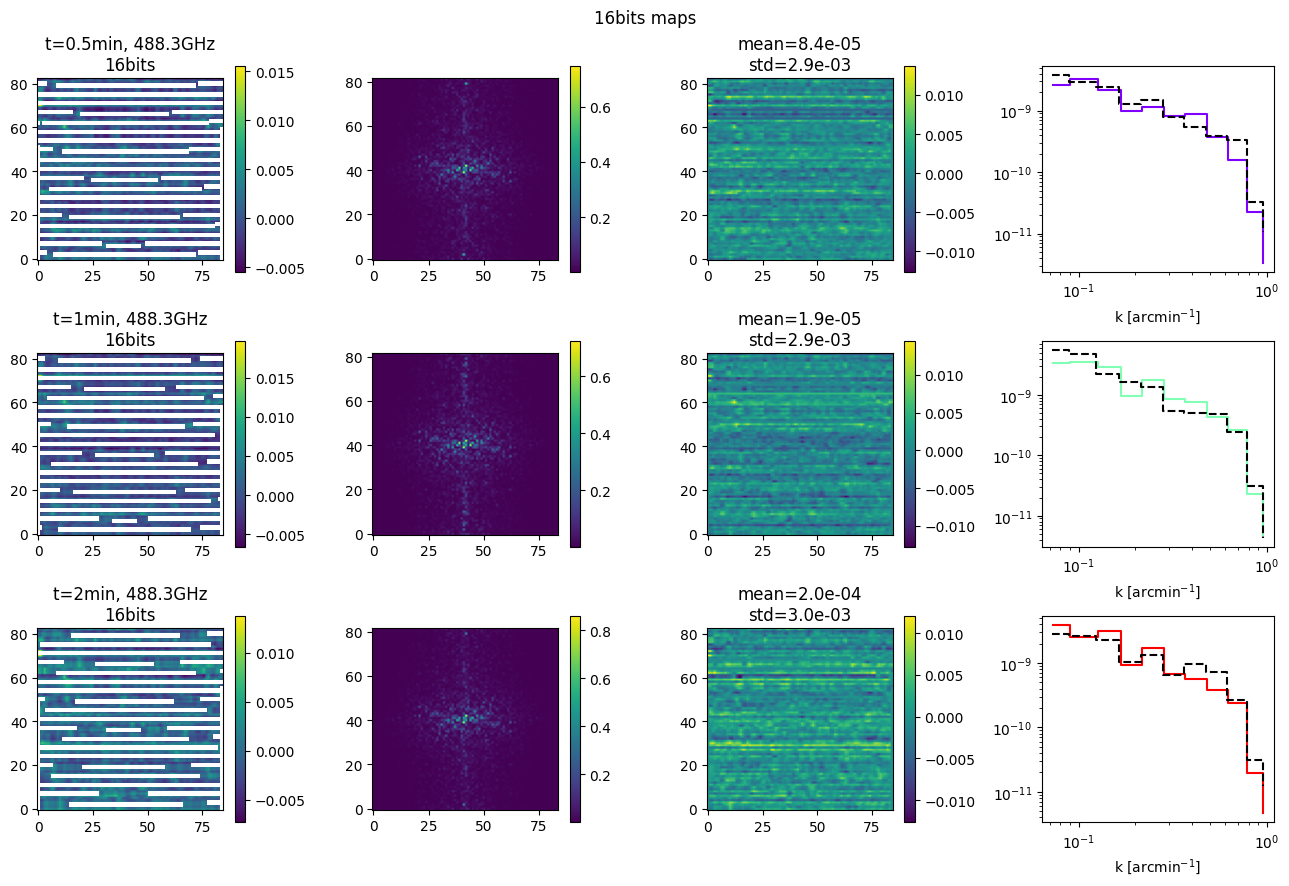

In [7]:
if(True): 
    for precision in ('32bits', '16bits'):

        fig, axs = plt.subplots(len(times),4,figsize=(13,len(times)*3))
        fig.suptitle(f'{precision} maps')

        for t, (time, c) in enumerate(zip(times,colors)):

            par = load_par_file(f'params_ref_namap.par')
            file = f'TOD_{format_duration(time/60)}_{precision}_data488.3Hz_coords488.3Hz.hdf5'
            par['hdf5_file'] = f'/home/mvancuyck/Desktop/TODs_profiling/{file}' 
            par['cdelt'] = res/3600, res/3600
            par['output_map'] = f"coadded_map_{len(par['frequencies'])}bands_{file[-5]}.fits"
            par['bypass_synch'] = True
            main(par)
            #---

            Map = fits.getdata(f"fits_and_hdf5/{par['output_map']}")
            im = axs[t,0].imshow(Map, origin='lower'); 
            axs[t,0].set_title(f't={time}min, 488.3GHz\n{precision}')
            fig.colorbar(im, ax=axs[t,0], orientation='vertical')
            Map = np.nan_to_num(Map, nan=0.0, posinf=0.0, neginf=0.0)
            fft2 = np.fft.fft2(Map)
            fft2_shifted = np.fft.fftshift(fft2[1:,1:])  # center zero frequency
            power = np.abs(fft2_shifted)**2
            im2 = axs[t,1].imshow(power, origin='lower')
            fig.colorbar(im2, ax=axs[t,1], orientation='vertical')
            k_nyquist, k_min, k_bin_width, k_bin_tab, k_out, k_map = set_k_infos(Map.shape[0], Map.shape[1], res/3600*u.deg, delta_k_over_k = 0.3)
            pk,k = power_spectral_density(Map, res=res/3600*u.deg, bins=k_bin_tab)
            axs[t,3].step(k_out[1:].to(1/u.arcmin),pk[1:], where='mid',color=c)
            axs[t,3].set_xscale('log'); axs[t,3].set_yscale('log')
            axs[t,3].set_xlabel('k [$\\rm arcmin^{-1}$]')
            

            ref_pk = dict_ref[f't={format_duration(time/60)}']['pk']
            ref_k  = dict_ref[f't={format_duration(time/60)}']['k [arcmin-1]']
            axs[t,3].step(ref_k,ref_pk, where='mid',color='k', ls='--')     
            map_ref = dict_ref[f't={format_duration(time/60)}']['map']
            map_ref = np.nan_to_num(map_ref, nan=0.0, posinf=0.0, neginf=0.0)
            diff_map = Map-map_ref[:Map.shape[0],:]
            im3 = axs[t,2].imshow(diff_map, origin='lower')
            axs[t,2].set_title(f'mean={diff_map.mean():.1e}\nstd={diff_map.std():.1e}')
            fig.colorbar(im3, ax=axs[t,2], orientation='vertical')
        
        fig.tight_layout()

Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


...

/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


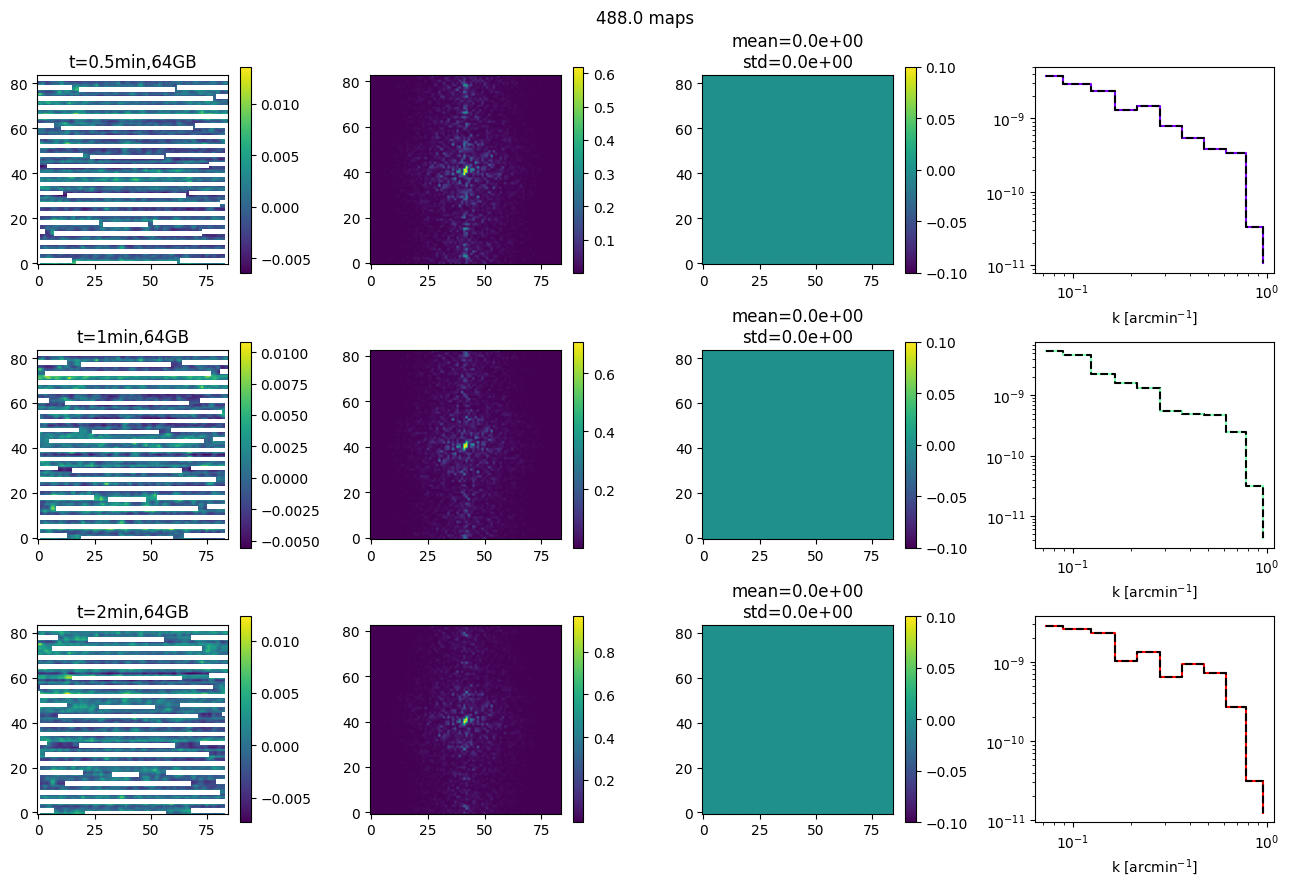

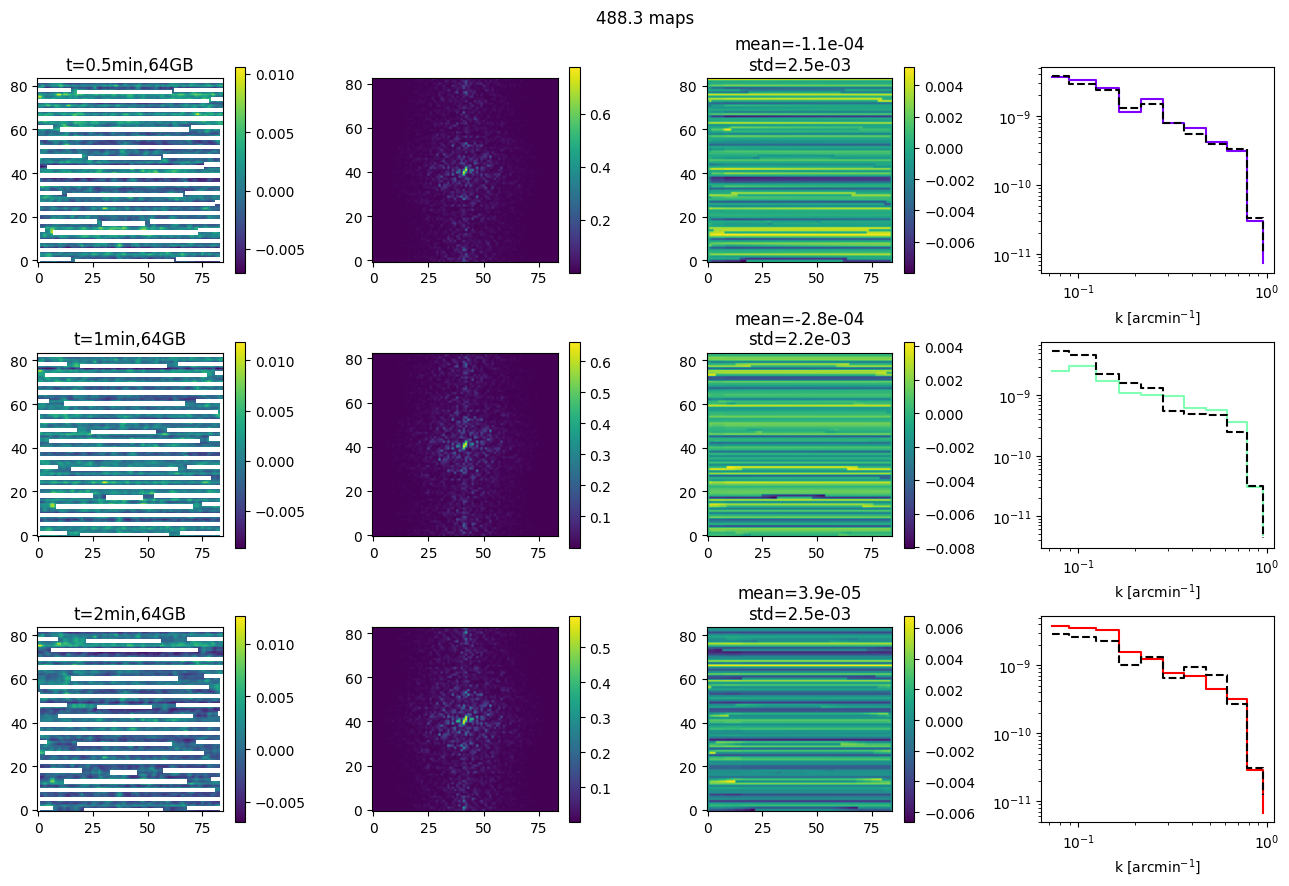

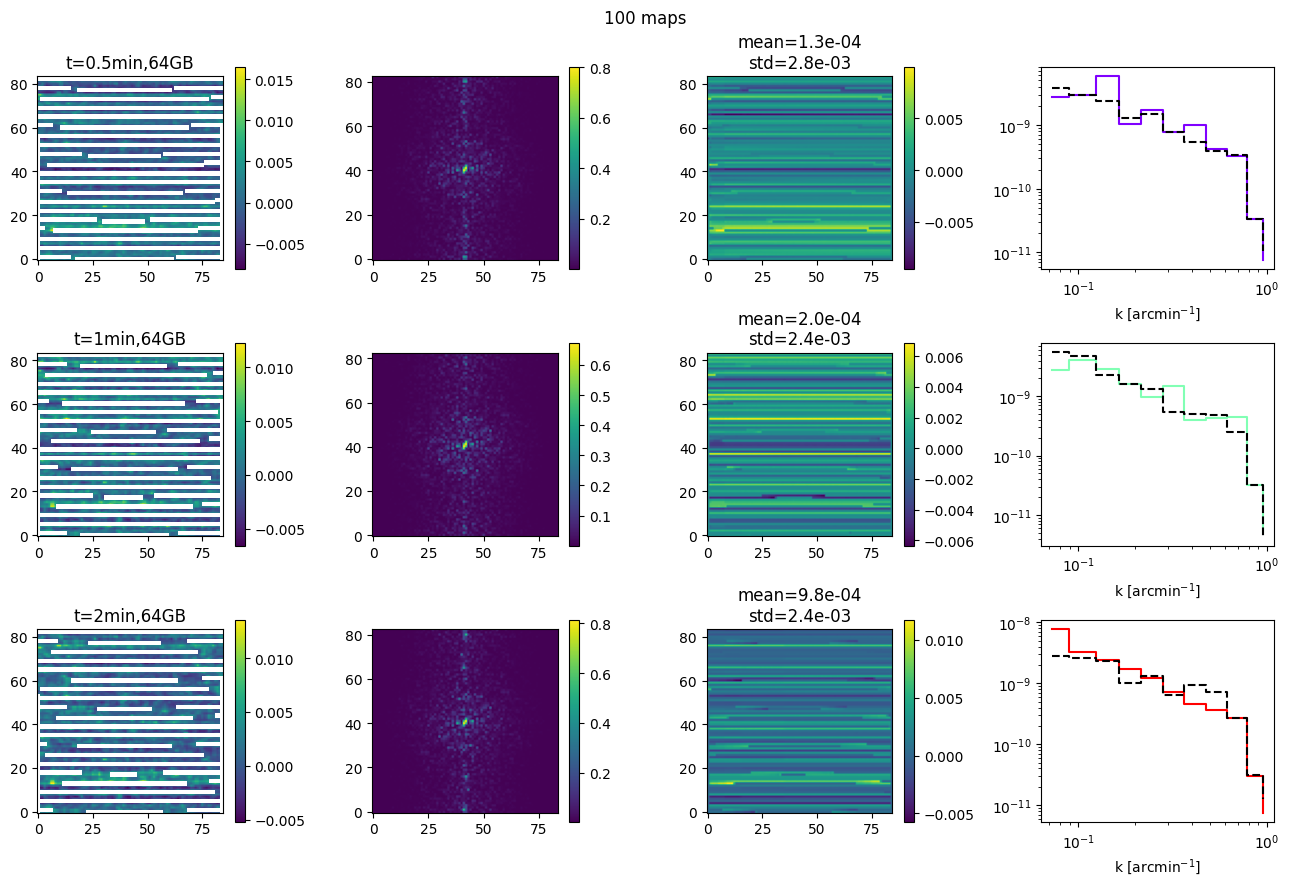

In [11]:
if(True): 
    for freq in (488.0,488.3, 100):

        fig, axs = plt.subplots(len(times),4,figsize=(13,len(times)*3))
        fig.suptitle(f'{freq} maps')

        for t, (time, c) in enumerate(zip(times,colors)):

            par = load_par_file(f'params_ref_namap.par')
            file = f'TOD_{format_duration(time/60)}_64bits_data{freq:.1f}Hz_coords{freq:.1f}Hz.hdf5'
            par['hdf5_file'] = f'/home/mvancuyck/Desktop/TODs_profiling/{file}' 
            par['cdelt'] = res/3600, res/3600
            par['output_map'] = f"coadded_map_{len(par['frequencies'])}bands_{file[-5]}.fits"
            par['bypass_synch'] = True
            main(par)
            #---

            Map = fits.getdata(f"fits_and_hdf5/{par['output_map']}")
            im = axs[t,0].imshow(Map, origin='lower'); 
            axs[t,0].set_title(f't={time}min,64GB')
            fig.colorbar(im, ax=axs[t,0], orientation='vertical')
            Map = np.nan_to_num(Map, nan=0.0, posinf=0.0, neginf=0.0)
            fft2 = np.fft.fft2(Map)
            fft2_shifted = np.fft.fftshift(fft2[1:,1:])  # center zero frequency
            power = np.abs(fft2_shifted)**2
            im2 = axs[t,1].imshow(power, origin='lower')
            fig.colorbar(im2, ax=axs[t,1], orientation='vertical')
            k_nyquist, k_min, k_bin_width, k_bin_tab, k_out, k_map = set_k_infos(Map.shape[0], Map.shape[1], res/3600*u.deg, delta_k_over_k = 0.3)
            pk,k = power_spectral_density(Map, res=res/3600*u.deg, bins=k_bin_tab)
            axs[t,3].step(k_out[1:].to(1/u.arcmin),pk[1:], where='mid',color=c)
            axs[t,3].set_xscale('log'); axs[t,3].set_yscale('log')
            axs[t,3].set_xlabel('k [$\\rm arcmin^{-1}$]')
            

            ref_pk = dict_ref[f't={format_duration(time/60)}']['pk']
            ref_k  = dict_ref[f't={format_duration(time/60)}']['k [arcmin-1]']
            axs[t,3].step(ref_k,ref_pk, where='mid',color='k', ls='--')     
            map_ref = dict_ref[f't={format_duration(time/60)}']['map']
            map_ref = np.nan_to_num(map_ref, nan=0.0, posinf=0.0, neginf=0.0)
            diff_map = Map-map_ref[:Map.shape[0],:]
            im3 = axs[t,2].imshow(diff_map, origin='lower')
            axs[t,2].set_title(f'mean={diff_map.mean():.1e}\nstd={diff_map.std():.1e}')
            fig.colorbar(im3, ax=axs[t,2], orientation='vertical')
        
        fig.tight_layout()

Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


...

/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


Using numeric dtype: <class 'numpy.float64'>
Nb dets:  64


/home/mvancuyck/Desktop/TIM_analysis/namap/src/mapmaker.py:351: RuntimeWarning: invalid value encountered in divide
  hist /= norm
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/astropy/units/quantity.py:666: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


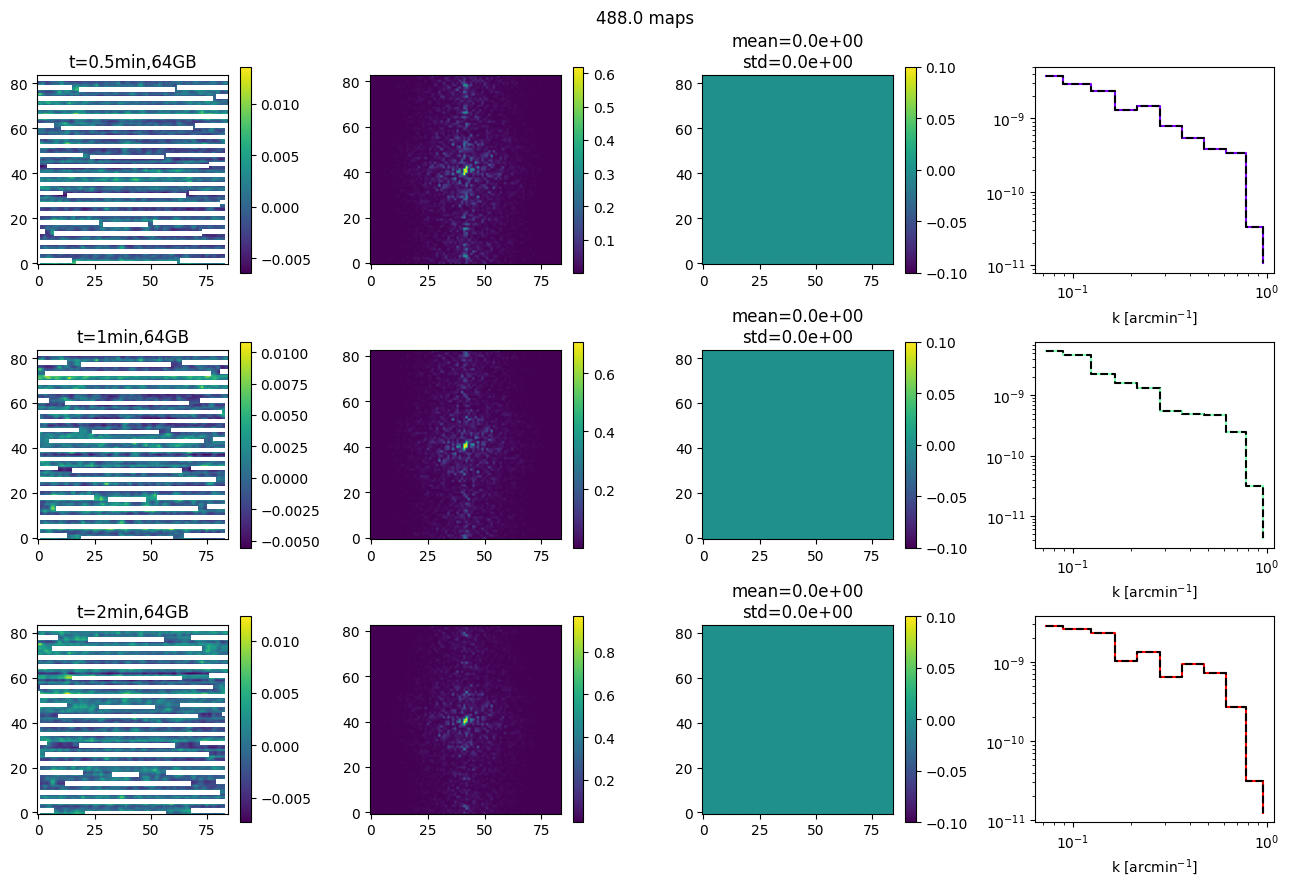

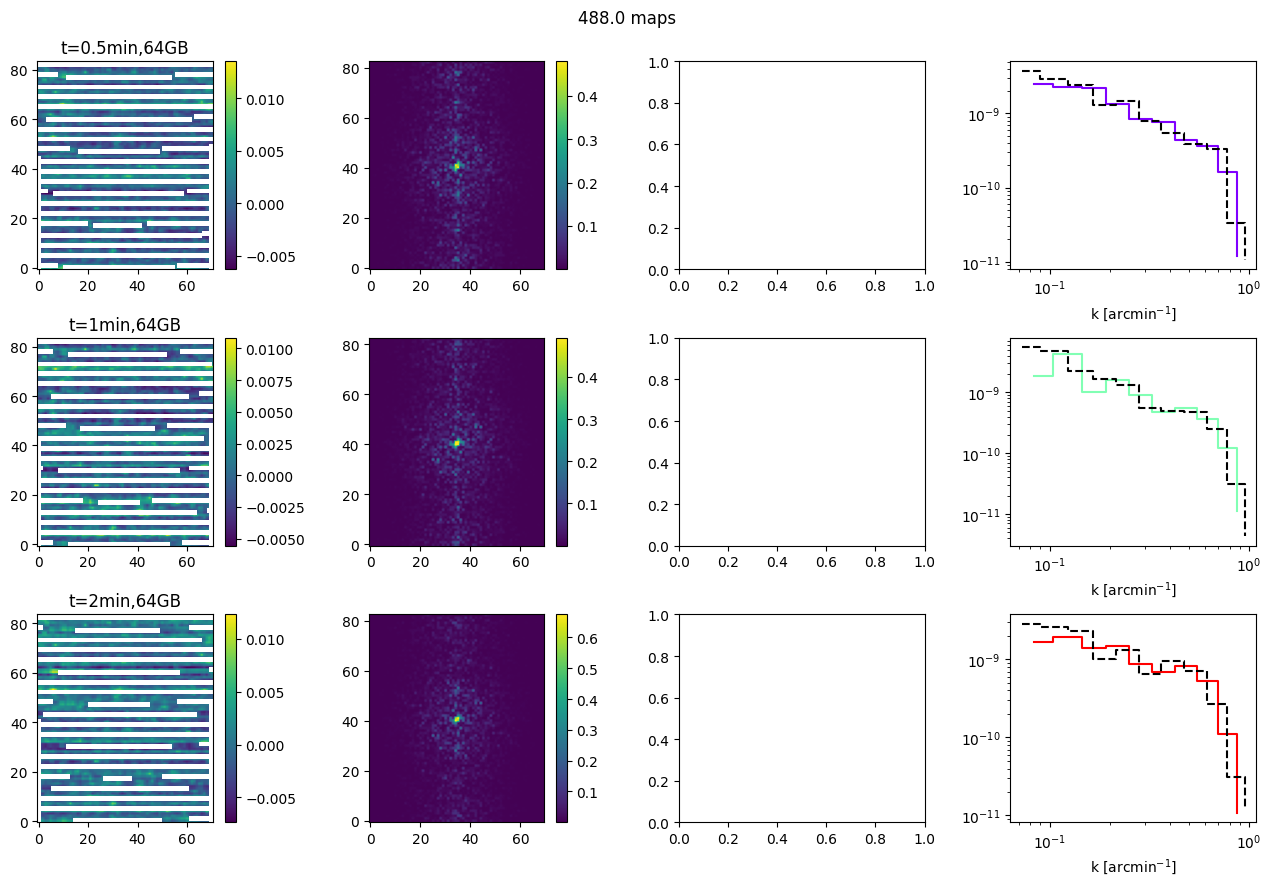

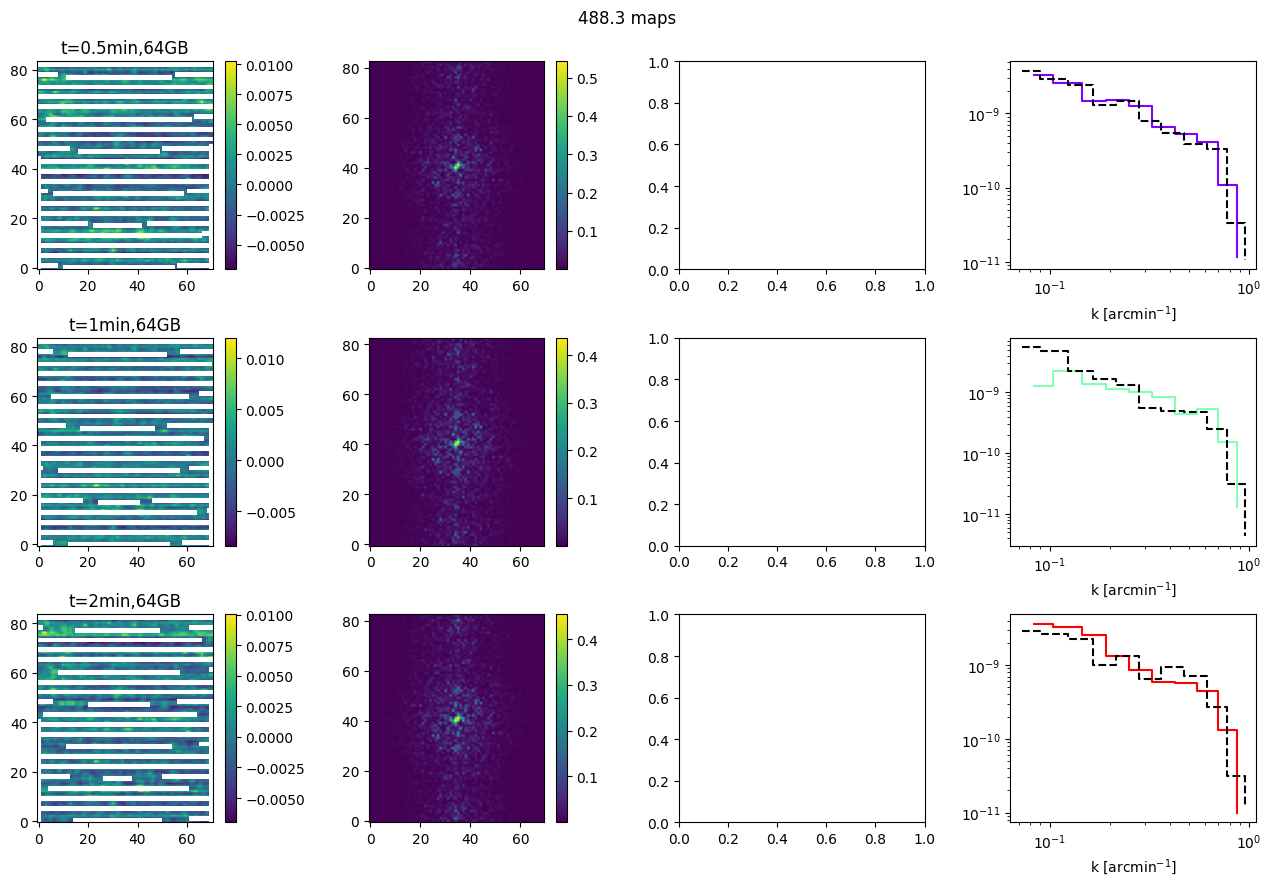

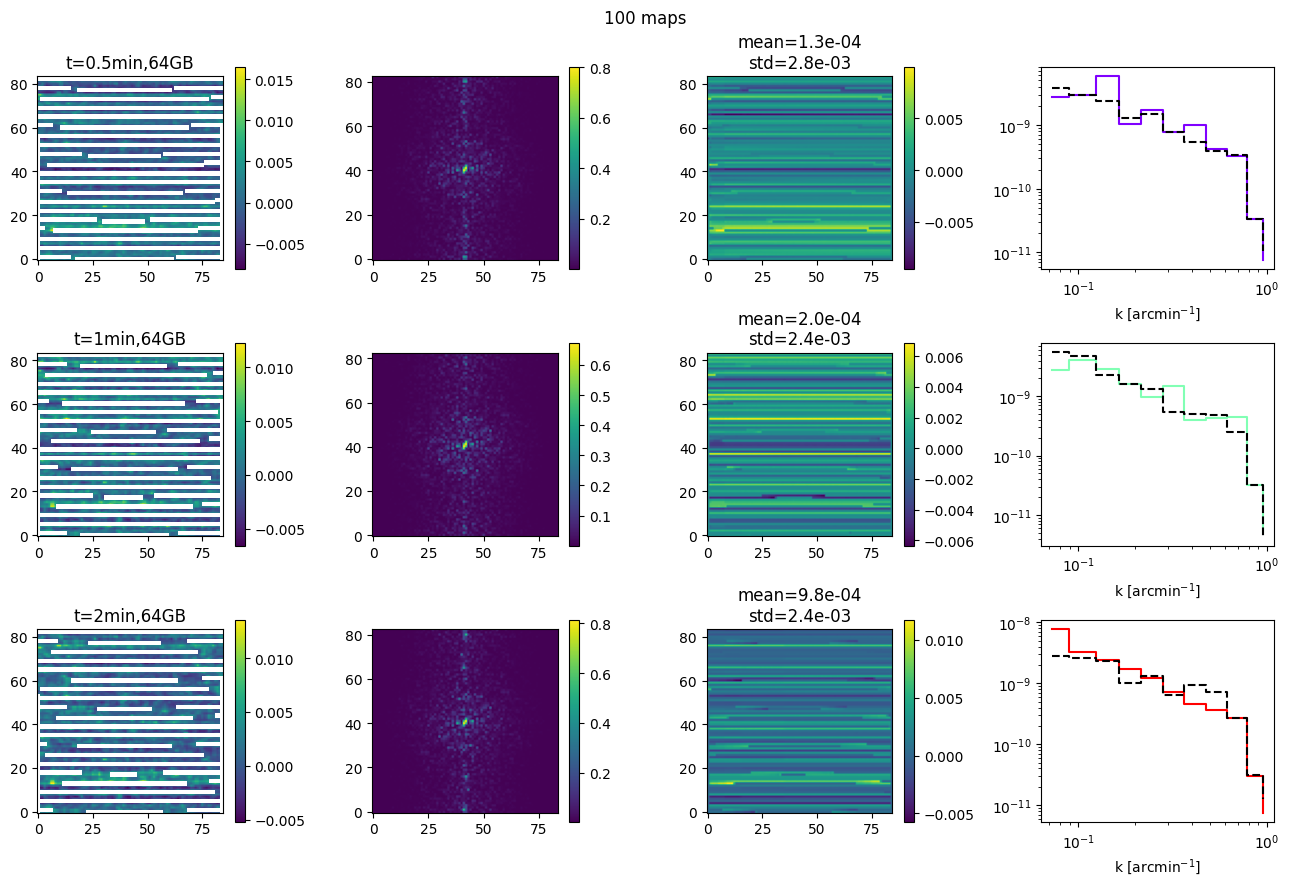

In [16]:
if(True): 
    for freq, bypass in zip((488.0, 488.0,488.3, 100), (True, False, False, True)):

        fig, axs = plt.subplots(len(times),4,figsize=(13,len(times)*3))
        fig.suptitle(f'{freq} maps')

        for t, (time, c) in enumerate(zip(times,colors)):

            par = load_par_file(f'params_ref_namap.par')
            file = f'TOD_{format_duration(time/60)}_64bits_data{freq:.1f}Hz_coords{freq:.1f}Hz.hdf5'
            par['hdf5_file'] = f'/home/mvancuyck/Desktop/TODs_profiling/{file}' 
            par['cdelt'] = res/3600, res/3600
            par['output_map'] = f"coadded_map_{len(par['frequencies'])}bands_{file[-5]}.fits"
            par['bypass_synch'] = bypass
            main(par)
            #---

            Map = fits.getdata(f"fits_and_hdf5/{par['output_map']}")
            im = axs[t,0].imshow(Map, origin='lower'); 
            axs[t,0].set_title(f't={time}min,64GB')
            fig.colorbar(im, ax=axs[t,0], orientation='vertical')
            Map = np.nan_to_num(Map, nan=0.0, posinf=0.0, neginf=0.0)
            fft2 = np.fft.fft2(Map)
            fft2_shifted = np.fft.fftshift(fft2[1:,1:])  # center zero frequency
            power = np.abs(fft2_shifted)**2
            im2 = axs[t,1].imshow(power, origin='lower')
            fig.colorbar(im2, ax=axs[t,1], orientation='vertical')
            k_nyquist, k_min, k_bin_width, k_bin_tab, k_out, k_map = set_k_infos(Map.shape[0], Map.shape[1], res/3600*u.deg, delta_k_over_k = 0.3)
            pk,k = power_spectral_density(Map, res=res/3600*u.deg, bins=k_bin_tab)
            axs[t,3].step(k_out[1:].to(1/u.arcmin),pk[1:], where='mid',color=c)
            axs[t,3].set_xscale('log'); axs[t,3].set_yscale('log')
            axs[t,3].set_xlabel('k [$\\rm arcmin^{-1}$]')
            

            ref_pk = dict_ref[f't={format_duration(time/60)}']['pk']
            ref_k  = dict_ref[f't={format_duration(time/60)}']['k [arcmin-1]']
            axs[t,3].step(ref_k,ref_pk, where='mid',color='k', ls='--')     
            map_ref = dict_ref[f't={format_duration(time/60)}']['map']
            map_ref = np.nan_to_num(map_ref, nan=0.0, posinf=0.0, neginf=0.0)
            if(map_ref.shape == Map.shape): 
                diff_map = Map-map_ref[:Map.shape[0],:Map.shape[1]]
                im3 = axs[t,2].imshow(diff_map, origin='lower')
                axs[t,2].set_title(f'mean={diff_map.mean():.1e}\nstd={diff_map.std():.1e}')
                fig.colorbar(im3, ax=axs[t,2], orientation='vertical')
        
        fig.tight_layout()